# 1. Preuzimanje i inicijalna analiza podataka
## Projekat OnlyFacts - Detekcija lažnih vesti u SAD za 2017. godinu

### 1.1 Ucitavanje biblioteka i podataka

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# Ucitavanje podataka
true_df = pd.read_csv('data/true.csv')
fake_df = pd.read_csv('data/fake.csv')

# Dodavanje labele: 1 = istinita vest, 0 = lazna vest
true_df['label'] = 1
fake_df['label'] = 0

print(f'Skup istinitih vesti: {true_df.shape[0]} redova, {true_df.shape[1]} kolona')
print(f'Skup laznih vesti:    {fake_df.shape[0]} redova, {fake_df.shape[1]} kolona')

### 1.2 Pregled strukture podataka

In [ ]:
print('ISTINITE VESTI')
print(true_df.info())
print('\nPrvih 5 redova:')
true_df.head()

In [ ]:
print('LAZNE VESTI')
print(fake_df.info())
print('\nPrvih 5 redova:')
fake_df.head()

### 1.3 Provera nedostajucih vrednosti

In [ ]:
print('NEDOSTAJUCE VREDNOSTI')
print('\nIstinite vesti:')
print(true_df.isnull().sum())
print(f'Ukupno: {true_df.isnull().sum().sum()}')

print('\nLazne vesti:')
print(fake_df.isnull().sum())
print(f'Ukupno: {fake_df.isnull().sum().sum()}')

### 1.4 Provera duplikata

In [ ]:
print('DUPLIKATI')
print(f'Duplikati u istinitim vestima: {true_df.duplicated().sum()}')
print(f'Duplikati u laznim vestima:    {fake_df.duplicated().sum()}')

# Provera duplikata samo po tekstu, u slucaju da imamo isti tekst sa razlicitim naslovima
print(f'\nDuplikati po koloni "text" - istinite: {true_df["text"].duplicated().sum()}')
print(f'Duplikati po koloni "text" - lazne:    {fake_df["text"].duplicated().sum()}')

### 1.5 Spajanje u jedan dataset i distribucija klasa (provera balansiranosti klasa)

In [ ]:
# Spajanje skupova
df = pd.concat([true_df, fake_df], ignore_index=True)
print(f'Ukupan broj clanaka: {df.shape[0]}')
print(f'\nDistribucija klasa:')
print(df['label'].value_counts())
print(f'\nProcenat istinitih: {df["label"].mean()*100:.1f}%')
print(f'Procenat laznih:    {(1 - df["label"].mean())*100:.1f}%')

In [ ]:
# Vizuelizacija distribucije klasa
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_xticklabels(['Lazne (0)', 'Istinite (1)'], rotation=0)
ax.set_title('Distribucija klasa')
ax.set_ylabel('Broj clanaka')
plt.tight_layout()
plt.show()

### 1.6 Analiza kategorija (subject)

In [ ]:
print('Kategorije u istinitim vestima:')
print(true_df['subject'].value_counts())
print(f'\nKategorije u laznim vestima:')
print(fake_df['subject'].value_counts())

In [ ]:
# Vizuelizacija kategorija po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

true_df['subject'].value_counts().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Kategorije - Istinite vesti')
axes[0].set_xlabel('Broj clanaka')

fake_df['subject'].value_counts().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Kategorije - Lazne vesti')
axes[1].set_xlabel('Broj clanaka')

plt.tight_layout()
plt.show()

### 1.7 Statistike teksta

In [ ]:
# Duzina teksta (broj karaktera i broj reci)
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['title_length'] = df['title'].astype(str).apply(len)

print('STATISTIKE TEKSTA')
print('\nBroj reci u clanku:')
print(df.groupby('label')['word_count'].describe().round(1))
print('\nDuzina naslova (karakteri):')
print(df.groupby('label')['title_length'].describe().round(1))

In [ ]:
# Vizuelizacija distribucije duzine teksta po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label']==1]['word_count'].hist(bins=50, ax=axes[0], color='#2ecc71', alpha=0.7)
axes[0].set_title('Broj reci - Istinite vesti')
axes[0].set_xlabel('Broj reci')
axes[0].axvline(df[df['label']==1]['word_count'].mean(), color='black', linestyle='--', label='Srednja vrednost')
axes[0].legend()

df[df['label']==0]['word_count'].hist(bins=50, ax=axes[1], color='#e74c3c', alpha=0.7)
axes[1].set_title('Broj reci - Lazne vesti')
axes[1].set_xlabel('Broj reci')
axes[1].axvline(df[df['label']==0]['word_count'].mean(), color='black', linestyle='--', label='Srednja vrednost')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.8 Provera praznih/kratkih tekstova

In [ ]:
# Clanci sa praznim ili jako kratkim tekstom (manje od 10 reci)
short_texts = df[df['word_count'] < 10]
print(f'Broj clanaka sa manje od 10 reci: {len(short_texts)}')
if len(short_texts) > 0:
    print('\nPrimeri kratkih tekstova:')
    print(short_texts[['title', 'text', 'label']].head(10))

# Prazni naslovi
empty_titles = df[df['title'].astype(str).str.strip() == '']
print(f'\nBroj clanaka sa praznim naslovom: {len(empty_titles)}')

### 1.9 Najcesce reci po klasi

In [14]:
def get_top_words(texts, n=20):
    """Izdvaja n najcescih reci iz serije tekstova (bez kratkih reci)."""
    all_words = []
    for text in texts.astype(str):
        # Samo slova, lowercase
        words = re.findall(r'[a-zA-Z]{3,}', text.lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

top_true = get_top_words(df[df['label']==1]['text'])
top_fake = get_top_words(df[df['label']==0]['text'])


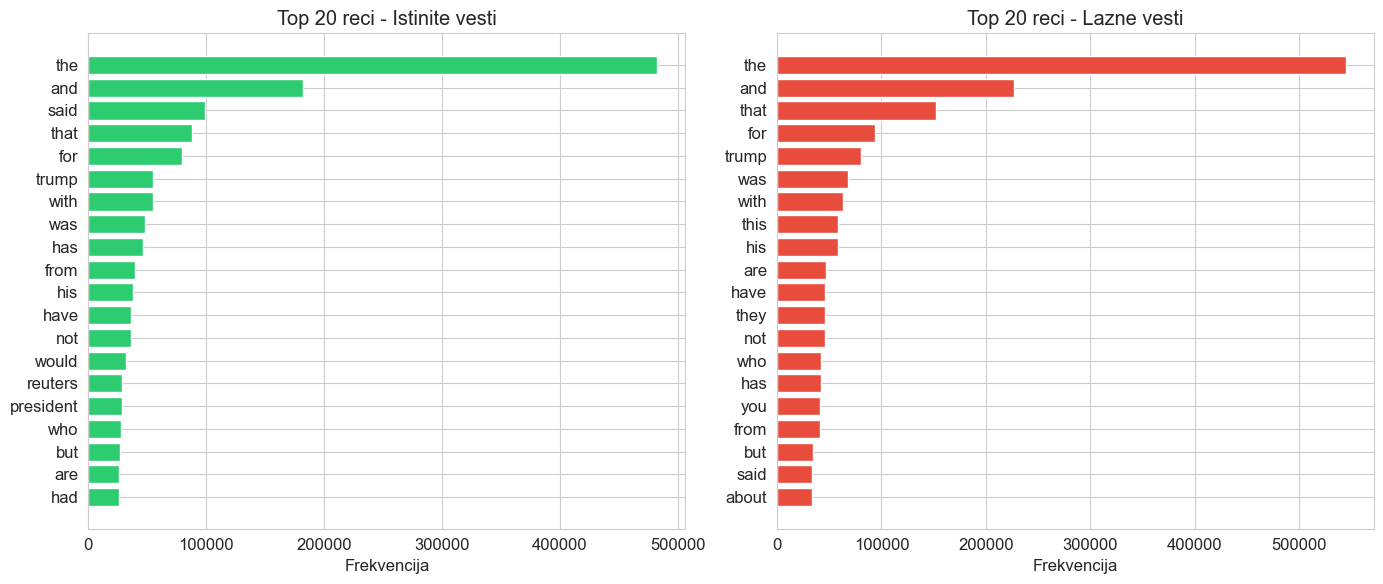

In [15]:
# Vizuelizacija top 20 reci po klasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_true, counts_true = zip(*top_true)
axes[0].barh(range(len(words_true)), counts_true, color='#2ecc71')
axes[0].set_yticks(range(len(words_true)))
axes[0].set_yticklabels(words_true)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 reci - Istinite vesti')
axes[0].set_xlabel('Frekvencija')

words_fake, counts_fake = zip(*top_fake)
axes[1].barh(range(len(words_fake)), counts_fake, color='#e74c3c')
axes[1].set_yticks(range(len(words_fake)))
axes[1].set_yticklabels(words_fake)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 reci - Lazne vesti')
axes[1].set_xlabel('Frekvencija')

plt.tight_layout()
plt.show()

### 1.10 Prisustvo URL-ova, specijalnih karaktera i velikih slova

In [16]:
# Analiza posebnih karakteristika teksta
df['has_url'] = df['text'].astype(str).str.contains(r'http[s]?://|www\.', regex=True)
df['exclamation_count'] = df['text'].astype(str).str.count('!')
df['caps_ratio'] = df['text'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)


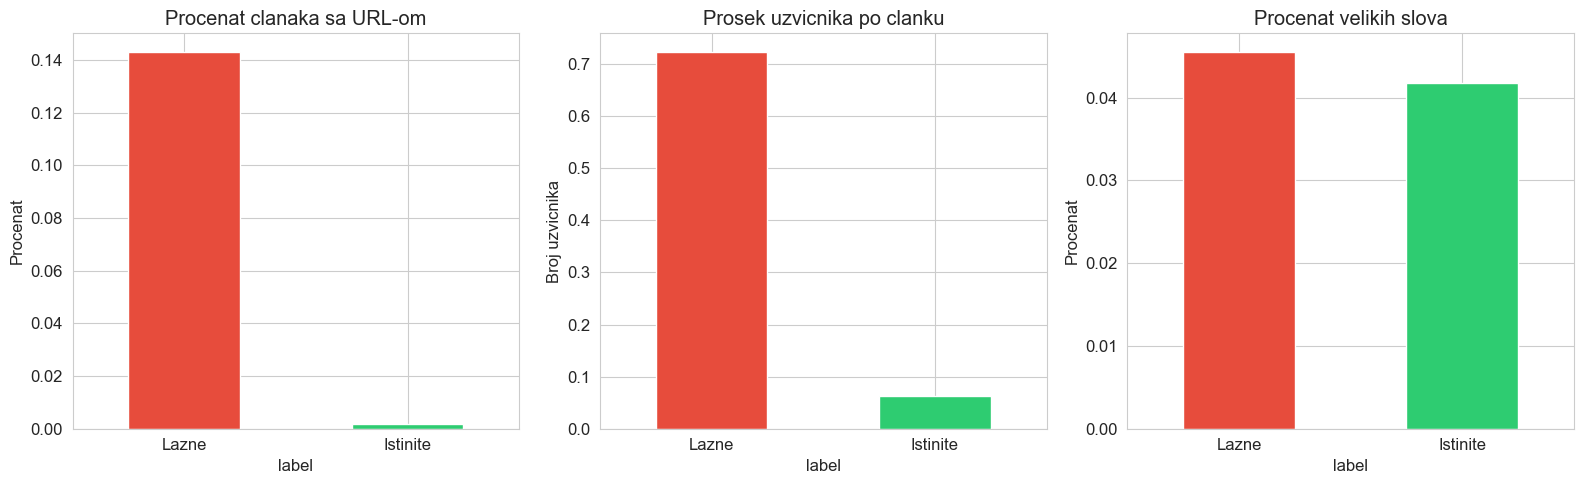

In [17]:
# Vizuelizacija razlika u stilu pisanja
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# URL-ovi
df.groupby('label')['has_url'].mean().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Procenat clanaka sa URL-om')
axes[0].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[0].set_ylabel('Procenat')

# Uzvicnici
df.groupby('label')['exclamation_count'].mean().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Prosek uzvicnika po clanku')
axes[1].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[1].set_ylabel('Broj uzvicnika')

# Velika slova
df.groupby('label')['caps_ratio'].mean().plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Procenat velikih slova')
axes[2].set_xticklabels(['Lazne', 'Istinite'], rotation=0)
axes[2].set_ylabel('Procenat')

plt.tight_layout()
plt.show()